pregunta 1: estampas repetidas al completar album (n=980)
repetidas totales media    : 6317.40
repetidas totales std      : 1272.04
repetidas primera mitad    : 187.09  (3.0%)
repetidas segunda mitad    : 6130.30  (97.0%)


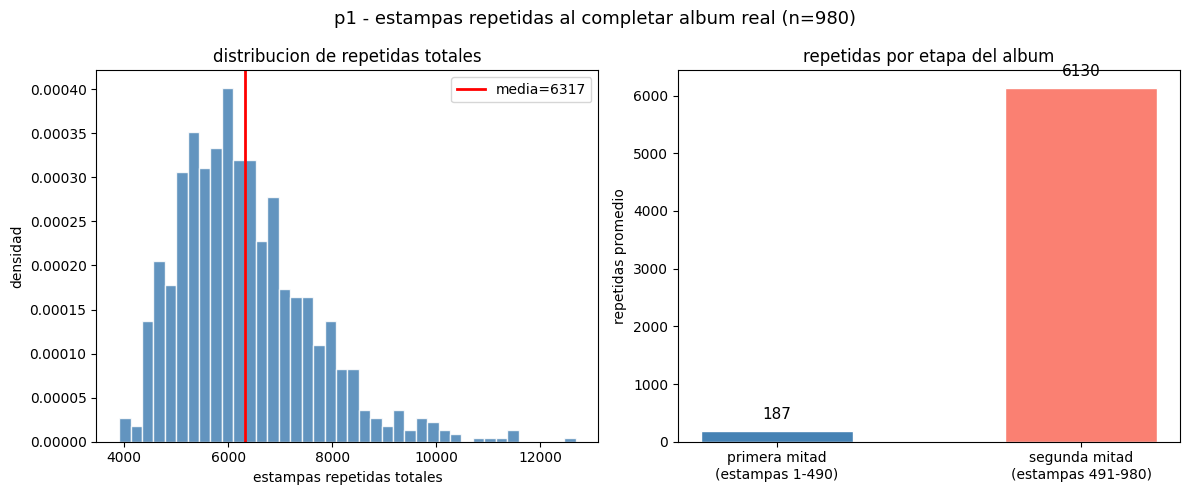


pregunta 2 inversion para 80% de probabilidad (n=980)
m=  950 sobres -> q9,025.00 -> prob=0.3750
m= 1000 sobres -> q9,500.00 -> prob=0.4630
m= 1050 sobres -> q9,975.00 -> prob=0.5960
m= 1100 sobres -> q10,450.00 -> prob=0.6680
m= 1150 sobres -> q10,925.00 -> prob=0.7630
m= 1200 sobres -> q11,400.00 -> prob=0.8430

>>> para 80% se necesitan 1200 sobres = q11,400.00


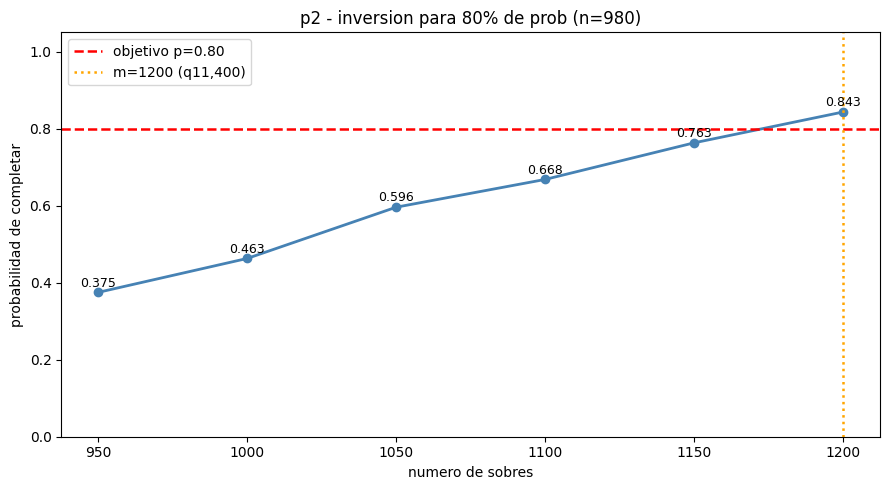


pregunta 3: k donde el intercambio deja de convenir
sin intercambio: 1042.48 sobres = q9,903.61
k=  1:   140.00 sobres = q 1,330.00  conveniente
k=  2:   193.80 sobres = q 1,841.06  conveniente
k=  5:   279.44 sobres = q 2,654.68  conveniente
k= 10:   352.16 sobres = q 3,345.48  conveniente
k= 20:   429.07 sobres = q 4,076.20  conveniente
k= 50:   531.05 sobres = q 5,044.97  conveniente

>>> en el rango explorado siempre conviene


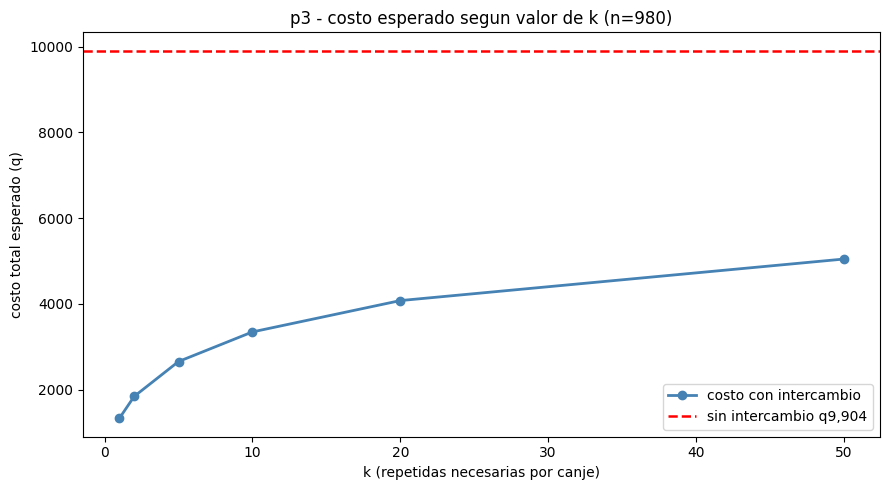


pregunta 4: cajas necesarias para completar (n=980)
cajas media             : 10.5700
cajas std               : 1.7763
cajas minimo/maximo     : 7 / 19
costo esperado          : q10,305.75
sobres equivalentes     : 1099.3


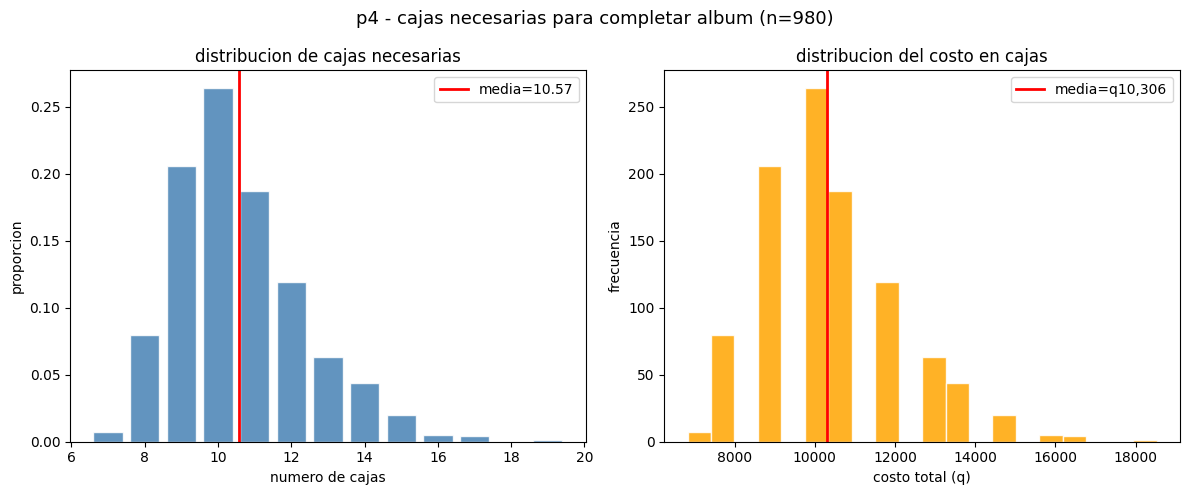


pregunta 5, peor escenario realista percentil 99 n=980
media (caso promedio)   : 1042 sobres  = q  9,903.61
percentil 50 (mediana)  : 1012 sobres  = q  9,614.00
percentil 90            : 1282 sobres  = q 12,179.00
percentil 95            : 1363 sobres  = q 12,948.98
percentil 99            : 1587 sobres  = q 15,076.78
maximo observado        : 1951 sobres  = q 18,534.50

exceso p99 vs media     : +545 sobres (+52.2%)
exceso en quetzales     : +q5,173.18


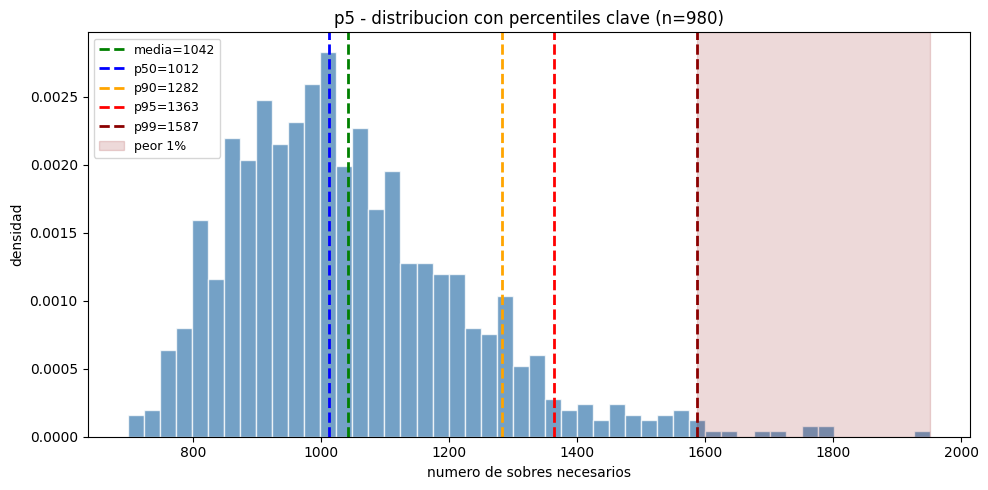

In [3]:
#Antony David Saz 24710
#Mariana castañeda 24481
# laboratorio 9 teoria de prob

import numpy as np
import matplotlib.pyplot as plt

n = 980; s = 7; r = 1000; precio = 9.50
precio_caja = 975.0; sobres_caja = 104

def sim_completar_base(n, s, r_sims, seed=2026):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(r_sims):
        album = np.zeros(n, dtype=bool); sob = 0
        while not album.all():
            album[rng.choice(n, s, replace=False)] = True; sob += 1
        out.append(sob)
    return np.array(out)

def sim_intercambio_fast(n, s, k, r_sims, seed=2026):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(r_sims):
        in_album = np.zeros(n, dtype=bool)
        missing = np.arange(n, dtype=np.int32)
        m_len = n; rep = 0; sob = 0
        while m_len > 0:
            nuevas = rng.choice(n, s, replace=False); sob += 1
            for e in nuevas:
                if in_album[e]: rep += 1
                else:
                    in_album[e] = True
                    idx = int(np.searchsorted(missing[:m_len], e))
                    missing[idx] = missing[m_len-1]; m_len -= 1
            missing[:m_len].sort()
            while rep >= k and m_len > 0:
                i = int(rng.integers(m_len))
                in_album[missing[i]] = True
                missing[i] = missing[m_len-1]; m_len -= 1
                rep -= k
            missing[:m_len].sort()
        out.append(sob)
    return np.array(out)


# pregunta 1, estampas repetidas y su distribucion

print("=" * 60)
print("pregunta 1: estampas repetidas al completar album (n=980)")
print("=" * 60)

rng1 = np.random.default_rng(2026)
rep_total_list = []; rep_1m_list = []; rep_2m_list = []

for _ in range(r):
    album = np.zeros(n, dtype=bool); sob = 0; rep = 0; r1 = 0; r2 = 0
    while not album.all():
        nuevas = rng1.choice(n, s, replace=False); sob += 1
        for e in nuevas:
            if album[e]:
                rep += 1
                if album.sum() < n // 2: r1 += 1
                else: r2 += 1
            else: album[e] = True
    rep_total_list.append(rep); rep_1m_list.append(r1); rep_2m_list.append(r2)

rep_arr = np.array(rep_total_list)
r1_arr  = np.array(rep_1m_list)
r2_arr  = np.array(rep_2m_list)

print(f"repetidas totales media    : {rep_arr.mean():.2f}")
print(f"repetidas totales std      : {rep_arr.std():.2f}")
print(f"repetidas primera mitad    : {r1_arr.mean():.2f}  ({r1_arr.mean()/rep_arr.mean()*100:.1f}%)")
print(f"repetidas segunda mitad    : {r2_arr.mean():.2f}  ({r2_arr.mean()/rep_arr.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(rep_arr, bins=40, color='steelblue', edgecolor='white', alpha=0.85, density=True)
axes[0].axvline(rep_arr.mean(), color='red', lw=2, label=f'media={rep_arr.mean():.0f}')
axes[0].set_xlabel('estampas repetidas totales'); axes[0].set_ylabel('densidad')
axes[0].set_title('distribucion de repetidas totales'); axes[0].legend()

cats = ['primera mitad\n(estampas 1-490)', 'segunda mitad\n(estampas 491-980)']
medias_rep = [r1_arr.mean(), r2_arr.mean()]
bars = axes[1].bar(cats, medias_rep, color=['steelblue','salmon'], edgecolor='white', width=0.5)
for bar, m in zip(bars, medias_rep):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+200, f'{m:.0f}', ha='center', fontsize=11)
axes[1].set_ylabel('repetidas promedio')
axes[1].set_title('repetidas por etapa del album')
plt.suptitle('p1 - estampas repetidas al completar album real (n=980)', fontsize=13)
plt.tight_layout(); plt.savefig('lab9b_p1.png', dpi=150); plt.show(); plt.close()



# pregunta 2,  inversion para 80% de prob

print("\n" + "=" * 60)
print("pregunta 2 inversion para 80% de probabilidad (n=980)")
print("=" * 60)

m_vals_p2 = [950, 1000, 1050, 1100, 1150, 1200]
probs_p2 = []
for m in m_vals_p2:
    rng2 = np.random.default_rng(2026)
    ex = sum(1 for _ in range(r)
             if (lambda a: [a.__setitem__(rng2.choice(n,s,replace=False),True) for _ in range(m)] or a.all())(np.zeros(n,dtype=bool)))
    # forma legible:
    ex = 0
    rng2 = np.random.default_rng(2026)
    for _ in range(r):
        album = np.zeros(n, dtype=bool)
        for _ in range(m):
            album[rng2.choice(n, s, replace=False)] = True
        if album.all(): ex += 1
    p = ex / r; probs_p2.append(p)
    print(f"m={m:>5} sobres -> q{m*precio:>8,.2f} -> prob={p:.4f}")

m80 = next((m for m, p in zip(m_vals_p2, probs_p2) if p >= 0.80), None)
if m80:
    print(f"\n>>> para 80% se necesitan {m80} sobres = q{m80*precio:,.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(m_vals_p2, probs_p2, marker='o', color='steelblue', lw=2)
ax.axhline(0.80, color='red', linestyle='--', lw=1.8, label='objetivo p=0.80')
if m80: ax.axvline(m80, color='orange', linestyle=':', lw=1.8, label=f'm={m80} (q{m80*precio:,.0f})')
for x, y in zip(m_vals_p2, probs_p2):
    ax.text(x, y+0.015, f'{y:.3f}', ha='center', fontsize=9)
ax.set_xlabel('numero de sobres'); ax.set_ylabel('probabilidad de completar')
ax.set_title('p2 - inversion para 80% de prob (n=980)')
ax.legend(); ax.set_ylim(0, 1.05); plt.tight_layout()
plt.savefig('lab9b_p2.png', dpi=150); plt.show(); plt.close()



# pregunta 3 a partir de que k el intercambio no conviene

print("\n" + "=" * 60)
print("pregunta 3: k donde el intercambio deja de convenir")
print("=" * 60)

datos_sin = sim_completar_base(n, s, r)
media_sin = datos_sin.mean()
costo_sin = media_sin * precio
print(f"sin intercambio: {media_sin:.2f} sobres = q{costo_sin:,.2f}")

k_lista = [1, 2, 5, 10, 20, 50]
medias_k3 = []; costos_k3 = []

for k in k_lista:
    datos_k = sim_intercambio_fast(n, s, k, r)
    mk = datos_k.mean(); ck = mk * precio
    medias_k3.append(mk); costos_k3.append(ck)
    tag = 'conveniente' if ck < costo_sin else '*** no conviene ***'
    print(f"k={k:>3}: {mk:>8.2f} sobres = q{ck:>9,.2f}  {tag}")

k_no = next((k for k, c in zip(k_lista, costos_k3) if c >= costo_sin), None)
print(f"\n>>> {'a partir de k='+str(k_no)+' no conviene' if k_no else 'en el rango explorado siempre conviene'}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_lista, costos_k3, marker='o', color='steelblue', lw=2, label='costo con intercambio')
ax.axhline(costo_sin, color='red', linestyle='--', lw=1.8, label=f'sin intercambio q{costo_sin:,.0f}')
ax.set_xlabel('k (repetidas necesarias por canje)')
ax.set_ylabel('costo total esperado (q)')
ax.set_title('p3 - costo esperado segun valor de k (n=980)')
ax.legend(); plt.tight_layout()
plt.savefig('lab9b_p3.png', dpi=150); plt.show(); plt.close()



# pregunta 4 cuantas cajas en promedio para completar

print("\n" + "=" * 60)
print("pregunta 4: cajas necesarias para completar (n=980)")
print("=" * 60)

rng4 = np.random.default_rng(2026)
cajas_list = []
for _ in range(r):
    album = np.zeros(n, dtype=bool); cajas = 0
    while not album.all():
        for _ in range(sobres_caja):
            album[rng4.choice(n, s, replace=False)] = True
        cajas += 1
    cajas_list.append(cajas)

cajas_arr = np.array(cajas_list)
costo_arr = cajas_arr * precio_caja

print(f"cajas media             : {cajas_arr.mean():.4f}")
print(f"cajas std               : {cajas_arr.std():.4f}")
print(f"cajas minimo/maximo     : {cajas_arr.min()} / {cajas_arr.max()}")
print(f"costo esperado          : q{costo_arr.mean():,.2f}")
print(f"sobres equivalentes     : {cajas_arr.mean()*sobres_caja:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vals, cnts = np.unique(cajas_arr, return_counts=True)
axes[0].bar(vals, cnts/r, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(cajas_arr.mean(), color='red', lw=2, label=f'media={cajas_arr.mean():.2f}')
axes[0].set_xlabel('numero de cajas'); axes[0].set_ylabel('proporcion')
axes[0].set_title('distribucion de cajas necesarias'); axes[0].legend()

axes[1].hist(costo_arr, bins=20, color='orange', edgecolor='white', alpha=0.85)
axes[1].axvline(costo_arr.mean(), color='red', lw=2, label=f'media=q{costo_arr.mean():,.0f}')
axes[1].set_xlabel('costo total (q)'); axes[1].set_ylabel('frecuencia')
axes[1].set_title('distribucion del costo en cajas'); axes[1].legend()

plt.suptitle('p4 - cajas necesarias para completar album (n=980)', fontsize=13)
plt.tight_layout(); plt.savefig('lab9b_p4.png', dpi=150); plt.show(); plt.close()



# pregunta 5 peor escenario realista, percentil 99

print("\n" + "=" * 60)
print("pregunta 5, peor escenario realista percentil 99 n=980")
print("=" * 60)

# reutilizar datos_sin de pregunta 3
sobres_p5 = datos_sin
media5 = sobres_p5.mean()
p50  = np.percentile(sobres_p5, 50)
p90  = np.percentile(sobres_p5, 90)
p95  = np.percentile(sobres_p5, 95)
p99  = np.percentile(sobres_p5, 99)
pmax = sobres_p5.max()

print(f"media (caso promedio)   : {media5:.0f} sobres  = q{media5*precio:>10,.2f}")
print(f"percentil 50 (mediana)  : {p50:.0f} sobres  = q{p50*precio:>10,.2f}")
print(f"percentil 90            : {p90:.0f} sobres  = q{p90*precio:>10,.2f}")
print(f"percentil 95            : {p95:.0f} sobres  = q{p95*precio:>10,.2f}")
print(f"percentil 99            : {p99:.0f} sobres  = q{p99*precio:>10,.2f}")
print(f"maximo observado        : {pmax:.0f} sobres  = q{pmax*precio:>10,.2f}")
print(f"\nexceso p99 vs media     : +{p99-media5:.0f} sobres (+{(p99-media5)/media5*100:.1f}%)")
print(f"exceso en quetzales     : +q{(p99-media5)*precio:,.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sobres_p5, bins=50, color='steelblue', edgecolor='white', alpha=0.75, density=True)
for val, col, lbl in [(media5,'green',f'media={media5:.0f}'),
                      (p50,'blue',f'p50={p50:.0f}'),
                      (p90,'orange',f'p90={p90:.0f}'),
                      (p95,'red',f'p95={p95:.0f}'),
                      (p99,'darkred',f'p99={p99:.0f}')]:
    ax.axvline(val, color=col, lw=2, linestyle='--', label=lbl)
ylim = ax.get_ylim()
ax.fill_betweenx([ylim[0], ylim[1]], p99, pmax, alpha=0.15, color='darkred', label='peor 1%')
ax.set_ylim(ylim)
ax.set_xlabel('numero de sobres necesarios'); ax.set_ylabel('densidad')
ax.set_title('p5 - distribucion con percentiles clave (n=980)')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('lab9b_p5.png', dpi=150); plt.show(); plt.close()


